# Decion Tree Classifier from scratch

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Intilaizing Node

In [ ]:
from os import CLD_CONTINUED
class Node:

  def __init__(self, feature = None, threshold = None, left = None, right = None, value = None):
    self.feature = feature
    self.threshold = threshold
    self.left = left
    self.right = right
    self.value = value



# Entropy Calculations

In [ ]:
def entropy(y):
    """Calculating Entropy."""
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    entropy_value = -np.sum(probabilities * np.log2(probabilities))
    return entropy_value

# Information gain Calcluations

In [ ]:
def information_gain(parent, left_child, right_child):
    """Calculating Information Gain."""

    parent_entropy = entropy(parent)

    # weight of each children
    left_weight = len(left_child) / len(parent)
    right_weight = len(right_child) / len(parent)

    # Entropy of left and right child
    left_entropy = entropy(left_child)
    right_entropy = entropy(right_child)

    # Weighted entropy calculation
    weighted_entropy = (left_entropy * left_weight + right_entropy * right_weight)

    info_gain = parent_entropy - weighted_entropy

    return info_gain


# Dataset splitting

In [ ]:
def split_dataset(X, y, feature, threshold):
    """Splitting the data"""

    # masking
    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold

    x_left = X[left_mask]
    x_right = X[right_mask]

    y_left = y[left_mask]
    y_right = y[right_mask]

    return x_left,x_right,y_left,y_right


# Best fit split according to threshold and infrmation gain

In [ ]:
def find_best_split(X, y):
    """Finding the best split"""

    best_gain = -1
    best_feature = None
    best_threshold = None

    n_features = X.shape[1]

    for feature in range(n_features):
      thresholds = np.unique(X[:,feature])

      for threshold in thresholds:

        x_left, x_right, y_left, y_right = split_dataset(X,y, feature, threshold)

        if len(y_left) == 0 or len(y_right) == 0:
          continue

        gain = information_gain(y, y_left, y_right)

        # update values
        if gain > best_gain:
          best_gain = gain
          best_feature = feature
          best_threshold = threshold

    return best_feature, best_threshold, best_gain

# Building Tree on the basis of splitt and threshold and node

In [ ]:
def build_tree(X, y):
      """Building the tree"""

      # Stop if node is pure
      if len(np.unique(y)) == 1:
        return Node(value = np.unique(y)[0])

      # Find best split
      best_feature, best_threshold, best_gain = find_best_split(X, y)

      # Stop if no information gain
      if best_gain == 0:

        values, counts = np.unique(y, return_counts=True)

        majority_class = values[np.argmax(counts)]

        return Node(value = majority_class)

      # Split dataset
      X_left, X_right, y_left, y_right = split_dataset(X, y, best_feature, best_threshold)

      # Build subtrees recursively
      left_child = build_tree(X_left, y_left)
      right_child = build_tree(X_right, y_right)

      # Create decision node
      return Node(feature = best_feature,threshold = best_threshold,left = left_child, right = right_child)


# Predict the class

In [ ]:
def predict_one(X, node):
    """Predicting the class"""

    if node.value is not None:
      return node.value

    if X[node.feature] <= node.threshold:
      return predict_one(X, node.left)
    else:
      return predict_one(X, node.right)


# Decision tree class

In [ ]:
class DecisionTree:

  def __init__(self):
    """Initializing the tree"""
    self.root = None

  def fit(self, X, y):
    """Fitting the data"""
    self.root = build_tree(X, y)

  def predict(self, X):
    """Predicting the class"""
    predictions = []

    for x in X:
      prediction = predict_one(x, self.root)
      predictions.append(prediction)

    return np.array(predictions)


# Testing on sample data


In [ ]:
X = np.array([
    [25],
    [30],
    [35],
    [40],
    [45],
    [50]
])

y = np.array([
    0,
    0,
    0,
    1,
    1,
    1
])

In [ ]:
tree = DecisionTree()
tree.fit(X,y)
sample = np.array([42])

predict_one(sample , tree.root)


np.int64(1)

In [ ]:
print(tree.root.feature)
print(tree.root.threshold)

0
35


In [ ]:
X_test = np.array([
    [20],
    [33],
    [38],
    [60]
])

predictions = tree.predict(X_test)

print(predictions)

[0 0 1 1]


In [ ]:
root = Node()
y = np.array([1, 1, 1, 0])
print(entropy(y))

0.8112781244591328


# Test Scratch model on Iris dataset

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

X = iris.data
y = iris.target

""" iris.feature_names and iris.target_names"""

# splitting the datatset in trainign ans testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

print("My iris model prediction", y_pred)

My iris model prediction [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [ ]:
# Checking accuracy of model

from sklearn.metrics import accuracy_score

accuracy_scratch = accuracy_score(y_test, y_pred)
print("Accuracy of my model", accuracy_scratch)
print(y_test)
print(y_pred)

Accuracy of my model 1.0
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


# Sklearn model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
# We can also write DecisionTreeClassifier(criterion= 'gini' or 'entropy' or'log_loss')

model.fit(X_train, y_train)

y_pred_sklearn = model.predict(X_test)

accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)

print("Accuracy of sklearn model", accuracy_sklearn)
print(y_test)
print(y_pred_sklearn)



Accuracy of sklearn model 1.0
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


# Compare

In [ ]:
print("Our Decision Tree Accuracy :", accuracy_scratch)
print("Sklearn Decision Tree Accuracy :", accuracy_sklearn)

Our Decision Tree Accuracy : 1.0
Sklearn Decision Tree Accuracy : 1.0


# Visulaization


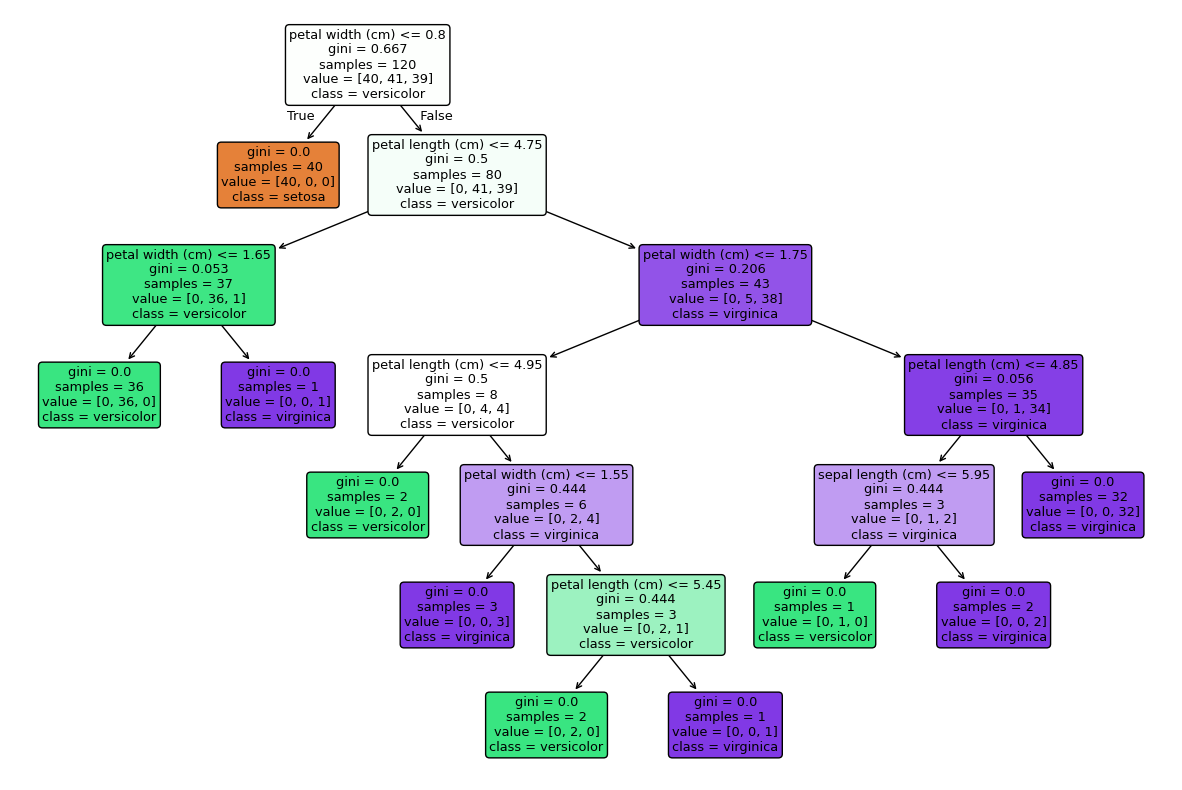

In [ ]:
from sklearn.tree import plot_tree


# plot tree
plt.figure(figsize=(15,10))
plot_tree(model, feature_names= iris.feature_names, class_names= iris.target_names , filled = True, rounded = True)
plt.savefig("decision_tree_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

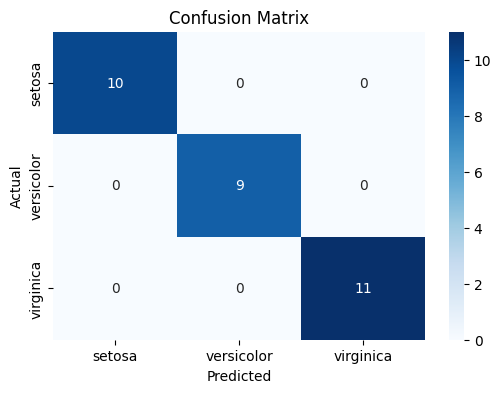

In [ ]:
# plot confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_sklearn)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

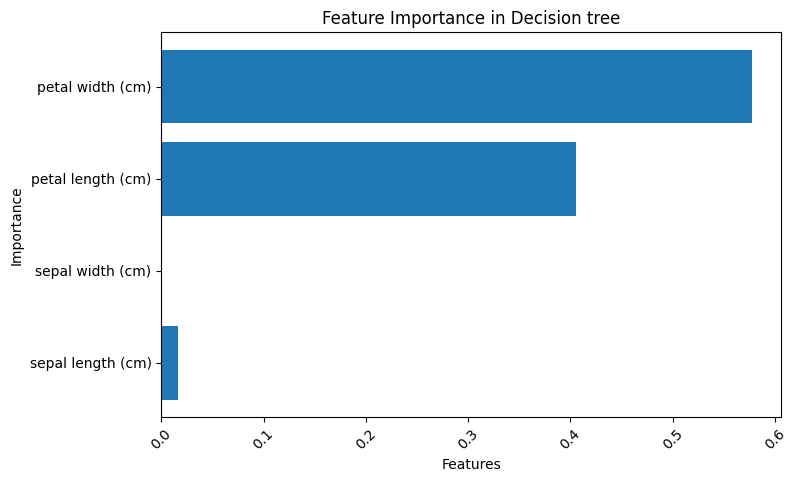

In [ ]:
# Visualize a feature imprtance

importance = model.feature_importances_

plt.figure(figsize=(8,5))

plt.barh(iris.feature_names, importance)

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance in Decision tree')
plt.xticks(rotation=45)
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()